# Cloud cover and cloud-top height prediction

The 2024 EUMETSAT satellite archive provides hourly cloud masks and cloud-top
heights. The first experiment estimates station cloud amount three hours ahead.
The second uses six satellite images to predict the cloud mask and cloud-top
height image for the following hour. I keep the experiments separate so each
result can be compared with its own baseline.

## Set up the notebook

Install the packages used to read the data, train the networks, and plot results.

In [1]:
%pip install matplotlib numpy pandas torch


Note: you may need to restart the kernel to use updated packages.


Import the numerical, plotting, and neural network libraries.

The same imports are shared by the station and cloud-map experiments.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math as maths
import torch, torch.nn as nn
import pandas as pd
import copy

torch.cuda.is_available()


False

Check the installed PyTorch version and available hardware.

In [3]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())


PyTorch: 2.14.0+cpu
CUDA available: False
GPU count: 0


## Read the satellite and station records

Keep the satellite times in UTC and align each hourly station record with its
satellite image before preparing model inputs.

Open the 2024 satellite archive and inspect its arrays.

In [4]:
sat_data = np.load( 
    "data/raw/satellite/ireland_clouds_20240101_20250101.npz"
)
print(sat_data.files)


['times', 'cloud_mask', 'cth_km', 'lat', 'lon']


List the five station files and define how their cloud-amount observations are read.

In [5]:
csv_name = ["hly532.csv","hly3904_subset.csv", "hly4935_subset.csv", "hly518_subset.csv", "hly3723_subset.csv"]

dates = []

def get_target_data(csv_name):
    data = pd.read_csv("data/raw/stations/"+csv_name,skiprows=41, low_memory=False)
    data = data.rename(columns={'ind': 'Rainfall_indicator', "ind.1": "Dry_bulb_indicator", "ind.2": "Wet_bulb_indicator", "ind.3": "wind_speed_indicator", "ind.4": "wind_dir_indicator"})
    numeric_like_cols = ["vappr", "rhum", "wddir", "vis", "clht", "clamt"]
    data[numeric_like_cols] = data[numeric_like_cols].apply(pd.to_numeric, errors="coerce")
    data[numeric_like_cols] = data[numeric_like_cols].ffill().bfill()

    data["date"] = pd.to_datetime(data["date"], format="%d-%b-%Y %H:%M")
    mask = data["date"].dt.year == 2024
    data = data[mask]
    target = data["clamt"].values
    print(f"{csv_name} target shape: {target.shape}")
    dates.append(data["date"].values)

    return target


Read the cloud-amount records for each station.

In [6]:
target_data = []

for csv in csv_name:
    target_data.append(get_target_data(csv))


hly532.csv target shape: (8784,)
hly3904_subset.csv target shape: (8784,)
hly4935_subset.csv target shape: (8784,)
hly518_subset.csv target shape: (8784,)
hly3723_subset.csv target shape: (8784,)


Confirm that all station files have matching hourly timestamps.

In [7]:
dates = np.array(dates).T
print(f"dates shape: {dates.shape}")

for date in dates:
    assert np.all(date[0] == date[1 :]), "Dates are not the same across all CSV files."


dates shape: (8784, 5)


Put the five station series into a single array.

In [8]:
target_data = np.array(target_data)
print(f"target_data shape: {target_data.shape}")


target_data shape: (5, 8784)


Match satellite and station timestamps hour by hour.

In [9]:
cloud_mask = sat_data["cloud_mask"]
cth_km = sat_data["cth_km"]
sat_times = sat_data["times"]

# station rows must be the same hours in the same order as the satellite frames (all UTC)
assert np.array_equal(dates[:, 0].astype("datetime64[us]"), sat_times)

# one True/False per HOUR: missing only if the WHOLE frame is "no data" (3)


Mark hours with valid satellite pixels and complete station targets.

In [10]:
sat_ok = ~(cloud_mask == 3).all(axis=(1, 2))                 # (8784,)

# target_data is (stations, hours): an hour is usable only if EVERY station has a cloud amount,
# so collapse the station axis -> one value per hour
target_ok = ~np.isnan(target_data).any(axis=0)               # (8784,)

hour_ok = sat_ok & target_ok
print(f"hours: {len(hour_ok)}, missing: {(~hour_ok).sum()}")
print("missing hours:", sat_times[~hour_ok])


hours: 8784, missing: 14
missing hours: ['2024-06-27T07:00:00.000000' '2024-07-23T22:00:00.000000'
 '2024-07-23T23:00:00.000000' '2024-07-24T00:00:00.000000'
 '2024-07-24T01:00:00.000000' '2024-07-24T02:00:00.000000'
 '2024-07-24T03:00:00.000000' '2024-07-24T04:00:00.000000'
 '2024-08-17T13:00:00.000000' '2024-08-17T14:00:00.000000'
 '2024-08-17T15:00:00.000000' '2024-08-17T16:00:00.000000'
 '2024-08-17T17:00:00.000000' '2024-09-04T08:00:00.000000']


Build the two image channels: cloud mask and cloud-top height.

In [11]:
# Build 2 channels per timestep -> frames: (hours, 2, 90, 120)
#   channel 0: cloud      1 = cloud, 0 = clear (clear sea / clear land / no-data pixel)
#   channel 1: height_km  cloud top height in km, 0 where clear
# Sea vs land never changes, so it's not worth a channel of its own.

cloud = (cloud_mask == 2).astype(np.float16)

# cth_km is NaN only in the 14 missing hours (those samples get dropped anyway) -> 0.
# CTH comes on a coarser grid, so it spills onto some clear pixels -- zero it wherever
# the cloud mask says clear so the two channels agree.
height_km = np.nan_to_num(cth_km, nan=0.0) * cloud

frames = np.stack([cloud, height_km], axis=1)    # float16 to save memory (~380 MB)



print(f"frames shape: {frames.shape}  (hours, channels, lat, lon)")
print(f"height range: {height_km.min():.2f} - {height_km.max():.2f} km")


frames shape: (8784, 2, 90, 120)  (hours, channels, lat, lon)
height range: 0.00 - 15.04 km


Release temporary arrays after the input frames are assembled.

In [12]:
import gc
del cloud, height_km, cth_km, sat_ok
gc.collect()


184

## Prepare the station prediction experiment

Six hourly images form each input. The station target is the change in cloud
amount three hours after the last image. The weekly split keeps examples from
the same week together.

Choose the six-hour history and three-hour station forecast horizon.

In [13]:
K = 6   # hours of satellite history per sample
H = 3   # predict cloud amount this many hours after the last input frame

# Don't delete the missing rows from the arrays -- that would join hours either side of a
# gap into one "continuous" sequence. Keep the full hourly arrays and instead list the
# samples that are valid: a sample ending at hour t uses frames t-K+1..t and target t+H,
# and is kept only if all of those hours are present.
sample_t = np.array([t for t in range(K - 1, len(hour_ok) - H)
                     if hour_ok[t - K + 1:t + 1].all() and hour_ok[t + H]])

print(f"possible samples: {len(hour_ok) - H - K + 1}, kept: {len(sample_t)}, "
      f"dropped: {len(hour_ok) - H - K + 1 - len(sample_t)}")

# e.g. inputs and target for the first valid sample


possible samples: 8776, kept: 8734, dropped: 42


Inspect the first image sequence and its station targets.

In [14]:
t = sample_t[0]
X0 = frames[t - K + 1:t + 1]        # (K, 2, 90, 120): K timesteps x 2 channels
y0 = target_data[:, t + H]          
print(X0.shape, y0)


(6, 2, 90, 120) [1. 7. 3. 7. 1.]


Express the station target as change from its latest observation.

In [15]:
clamt_now    = target_data[:, sample_t].T        # (samples, stations) cloud amount at the last input hour t
clamt_future = target_data[:, sample_t + H].T    # (samples, stations) cloud amount at t + H
y = clamt_future - clamt_now                     # (samples, stations) change in oktas over the next H hours
print(f"y shape: {y.shape}  (samples, stations)")


y shape: (8734, 5)  (samples, stations)


Add current station values and the target hour as model inputs.

In [16]:
# extra inputs per sample, joined to the CNN features before the final layer
#   clamt_now / 8        -> (samples, 5)  current cloud amount at each station, 0-1
#   sin/cos hour of day  -> (samples, 2)  hour of the TARGET (t + H), so 23h sits next to 0h
target_hour = sat_times[sample_t + H].astype("datetime64[h]").astype(int) % 24
extra = np.column_stack([
    clamt_now / 8.0,
    np.sin(2 * np.pi * target_hour / 24),
    np.cos(2 * np.pi * target_hour / 24),
]).astype(np.float32)
print(f"extra shape: {extra.shape}  (samples, 5 stations + 2 hour)")


extra shape: (8734, 7)  (samples, 5 stations + 2 hour)


Determine which examples fit entirely inside one week.

In [17]:
week_hours = 24 * 7
start_week = (sample_t - K + 1) // week_hours     # week of the sample's first input frame
end_week   = (sample_t + H) // week_hours         # week of its target hour
inside = start_week == end_week                   # the whole sample (inputs + target) sits in one week


Assign complete weeks to training, validation, and testing.

In [18]:
block = start_week % 7                            # every 7th week -> test, the next -> val, the rest -> train
idx = np.arange(len(sample_t))
train_idx = idx[inside & (block >= 2)]
val_idx   = idx[inside & (block == 1)]
test_idx  = idx[inside & (block == 0)]
print(len(train_idx), len(val_idx), len(test_idx), "dropped at week edges:", (~inside).sum())


5780 1265 1273 dropped at week edges: 416


Install scikit-learn for the station-only linear comparison.

In [19]:
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


Import the linear regression baseline.

In [20]:
from sklearn.linear_model import LinearRegression


Fit the linear model using the training weeks.

In [21]:
lin = LinearRegression().fit(extra[train_idx], y[train_idx])


Measure its station cloud-amount error on the test weeks.

In [22]:
lin_pred = np.clip(clamt_now[test_idx] + lin.predict(extra[test_idx]), 0, 8)
print(f"linear on extra only: overall RMSE {np.sqrt(((lin_pred - clamt_future[test_idx]) ** 2).mean()):.3f}")


linear on extra only: overall RMSE 1.539


Calculate the image-channel mean and spread.

In [23]:
def channel_stats(frames, hours, chunk=256):
    C = frames.shape[1]
    s, ss, count = np.zeros(C), np.zeros(C), 0
    for j in range(0, len(hours), chunk):
        b = frames[hours[j:j + chunk]].astype(np.float64)   # (b, C, 90, 120)
        s  += b.sum(axis=(0, 2, 3))                         # sum over everything except channel
        ss += (b ** 2).sum(axis=(0, 2, 3))
        count += b[:, 0].size
    mean = s / count
    std = np.sqrt(ss / count - mean ** 2)
    return mean, np.where(std == 0, 1.0, std)

# every input hour touched by a training sample (first frame of the first sample -> last frame of the last)


Compute image and station-target scaling values for model training.

In [24]:
train_hours = np.arange(sample_t[train_idx[0]] - K + 1, sample_t[train_idx[-1]] + 1)
train_hours = train_hours[hour_ok[train_hours]]             # skip the missing hours

x_mean, x_std = channel_stats(frames, train_hours)
y_mean, y_std = y[train_idx].mean(axis=0), y[train_idx].std(axis=0)


Define how one station example is loaded from the hourly arrays.

In [25]:
class FrameDataset(torch.utils.data.Dataset):
    def __init__(self, frames, extra, y, sample_t, idx, K):
        self.frames, self.extra, self.y, self.sample_t, self.idx, self.K = frames, extra, y, sample_t, idx, K
    def __len__(self):
        return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        t = self.sample_t[j]
        x = self.frames[t - self.K + 1:t + 1]
        return (torch.from_numpy(x.astype(np.float32)),
                torch.from_numpy(self.extra[j]),
                torch.from_numpy(self.y[j].astype(np.float32)))


Build separate station training, validation, and test loaders.

In [26]:
train_loader = torch.utils.data.DataLoader(FrameDataset(frames, extra, y, sample_t, train_idx, K), batch_size=32, shuffle=True)
val_loader   = torch.utils.data.DataLoader(FrameDataset(frames, extra, y, sample_t, val_idx, K),   batch_size=64)
test_loader  = torch.utils.data.DataLoader(FrameDataset(frames, extra, y, sample_t, test_idx, K),  batch_size=64)


## Station model: convolution and forward pass

As discussed in the lecture, a convolution learns small filters that scan an
image. Shared filters respond to local cloud patterns at many locations; the
activation adds nonlinearity. The station model puts six hourly images into
the CNN as channels and predicts five station values.

Keep the original ConvLSTM notes alongside the station-model setup.

In [27]:
###
#Failed attemp to use ConvLSTM from github
###
"""from class_convlstm import ConvLSTM

convlstm_layer = []
img_size_list = [(90, 120)]
num_layers = 3
input_channel = 2
hidden_channel = 64
kernel_size = (3, 3)
stride = (1, 1)
padding = (1, 1)
for i in range(num_layers):
    convlstm_layer.append(ConvLSTM(input_channel=input_channel, hidden_channel=hidden_channel, kernel_size=kernel_size,
                  stride=stride, padding=padding, batch_first=True)
    )
    input_channel = hidden_channel
"""


'from class_convlstm import ConvLSTM\n\nconvlstm_layer = []\nimg_size_list = [(90, 120)]\nnum_layers = 3\ninput_channel = 2\nhidden_channel = 64\nkernel_size = (3, 3)\nstride = (1, 1)\npadding = (1, 1)\nfor i in range(num_layers):\n    convlstm_layer.append(ConvLSTM(input_channel=input_channel, hidden_channel=hidden_channel, kernel_size=kernel_size,\n                  stride=stride, padding=padding, batch_first=True)\n    )\n    input_channel = hidden_channel\n'

Set the convolution dimensions used by the station CNN.

In [28]:
input_channel = 2
kernel_size = (3, 3)
stride = (2, 2)
padding = (0, 0)


Define a convolution, normalization, and activation block.

In [29]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(out_channels)    # matches out_channels
        self.gelu = nn.GELU()


    def forward(self, x):
        return self.gelu(self.bn(self.conv(x)))   # uses the names defined above


Define the station CNN. Its forward method extracts image features, joins the other inputs, and predicts station changes.

In [30]:
class CloudCNN(nn.Module):
    def __init__(self, K, n_channels, n_stations, n_extra):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(K * n_channels, 16, stride=stride, padding=padding, kernel_size=kernel_size),
            ConvBlock(16, 32, stride=stride, padding=padding, kernel_size=kernel_size),
            ConvBlock(32, 64, stride=stride, padding=padding, kernel_size=kernel_size),
        )
        self.pool = nn.Sequential(
            nn.AdaptiveAvgPool2d((6, 8)),              # -> (B, 64, 6, 8)
            nn.Flatten(),                              # -> (B, 3072)
        )
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(64 * 6 * 8 + n_extra, n_stations),   # -> (B, 5)
        )

    def forward(self, x, extra):
        B, K, C, H, W = x.shape
        x = x.reshape(B, K * C, H, W)
        z = self.pool(self.features(x))                # (B, 3072) image features
        z = torch.cat([z, extra], dim=1)               # (B, 3072 + 7)
        return self.head(z)


Define the scaling wrapper for the station model and its targets.

In [31]:
class ScaledModel(nn.Module):
    def __init__(self, net, x_mean, x_std, y_mean, y_std):
        super().__init__()
        self.net = net
        f = lambda a: torch.tensor(a, dtype=torch.float32)
        self.register_buffer("x_mean", f(x_mean).view(1, 1, -1, 1, 1))   # broadcasts over (B, K, C, H, W)
        self.register_buffer("x_std",  f(x_std).view(1, 1, -1, 1, 1))
        self.register_buffer("y_mean", f(y_mean).view(1, -1))            # broadcasts over (B, stations)
        self.register_buffer("y_std",  f(y_std).view(1, -1))

    def scale_y(self, y):                 # training targets -> scaled
        return (y - self.y_mean) / self.y_std

    def forward_scaled(self, x_raw, extra):      # raw frames -> scaled change (training)
        return self.net((x_raw - self.x_mean) / self.x_std, extra)

    def forward(self, x_raw, extra):             # raw frames -> change in oktas (test)
        return self.forward_scaled(x_raw, extra) * self.y_std + self.y_mean


Place the station model on the available device.

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ScaledModel(CloudCNN(K, frames.shape[1], y.shape[1], extra.shape[1]),
                    x_mean, x_std, y_mean, y_std).to(device)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")


parameters: 40,504


## Station model: loss and backward pass

The **forward pass** produces predicted station changes. The **loss** is mean
squared error between scaled predictions and scaled targets. In each training
batch, `zero_grad()` clears the previous gradients, `loss.backward()` carries
the new loss gradients back through the output layer and convolution filters,
and `optimizer.step()` updates their weights. Validation evaluates the same
loss without updating weights.

Set the station loss, optimizer, and learning-rate scheduler.

In [33]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)   # <- was Adam, lr=1e-3
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)


Set the number of epochs and initialize the loss records.

In [34]:
num_epochs = 50
best_val, best_state = float("inf"), None

train_loss_list, val_loss_list = [], []


Train the station model and check validation loss after every epoch.

In [35]:
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for xb, eb, yb in train_loader:
        xb, eb, yb = xb.to(device), eb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model.forward_scaled(xb, eb), model.scale_y(yb))
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, eb, yb in val_loader:
            xb, eb, yb = xb.to(device), eb.to(device), yb.to(device)
            val_loss += criterion(model.forward_scaled(xb, eb), model.scale_y(yb)).item() * len(xb)
    val_loss /= len(val_loader.dataset)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val, best_state = val_loss, copy.deepcopy(model.state_dict())

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    print(f"epoch {epoch + 1}: train {train_loss:.4f}  val {val_loss:.4f}  (scaled MSE)")


epoch 1: train 0.9998  val 0.9328  (scaled MSE)
epoch 2: train 0.9065  val 0.9301  (scaled MSE)
epoch 3: train 0.8551  val 0.9191  (scaled MSE)
epoch 4: train 0.8163  val 0.9233  (scaled MSE)
epoch 5: train 0.7782  val 0.9218  (scaled MSE)
epoch 6: train 0.7358  val 0.9342  (scaled MSE)
epoch 7: train 0.7033  val 0.9276  (scaled MSE)
epoch 8: train 0.6507  val 0.9325  (scaled MSE)
epoch 9: train 0.6311  val 0.9415  (scaled MSE)
epoch 10: train 0.6170  val 0.9566  (scaled MSE)
epoch 11: train 0.6012  val 0.9474  (scaled MSE)
epoch 12: train 0.5740  val 0.9466  (scaled MSE)
epoch 13: train 0.5715  val 0.9532  (scaled MSE)
epoch 14: train 0.5632  val 0.9530  (scaled MSE)
epoch 15: train 0.5541  val 0.9596  (scaled MSE)
epoch 16: train 0.5389  val 0.9514  (scaled MSE)
epoch 17: train 0.5407  val 0.9604  (scaled MSE)
epoch 18: train 0.5301  val 0.9599  (scaled MSE)
epoch 19: train 0.5292  val 0.9654  (scaled MSE)
epoch 20: train 0.5278  val 0.9640  (scaled MSE)
epoch 21: train 0.5228  val 0

Restore the station weights with the lowest validation loss.

In [36]:
model.load_state_dict(best_state)
print(f"best val: {best_val:.4f}")


best val: 0.9191


Plot the station training and validation losses.

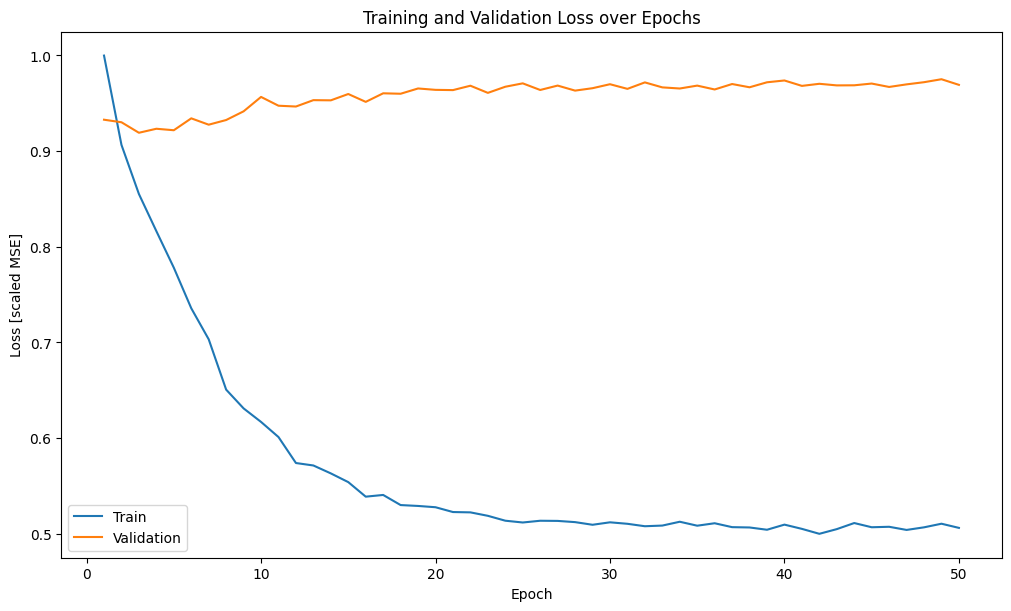

In [37]:
if len(train_loss_list) != len(val_loss_list):
    raise ValueError("Training and validation loss histories have different lengths.")

epochs = np.arange(1, len(train_loss_list) + 1)

fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
ax.plot(epochs, train_loss_list, label="Train")
ax.plot(epochs, val_loss_list, label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss [scaled MSE]")
ax.set_title("Training and Validation Loss over Epochs")
ax.legend()
plt.show()


Use the station model to predict the held-out weeks.

In [38]:
model.eval()
preds = []
with torch.no_grad():
    for xb, eb, _ in test_loader:
        preds.append(model(xb.to(device), eb.to(device)).cpu().numpy())    # plain forward -> change in oktas
# forecast = cloud amount now + predicted change, kept inside 0-8
preds = np.clip(clamt_now[test_idx] + np.concatenate(preds), 0, 8)
y_true = clamt_future[test_idx]

# baseline 1: persistence = the cloud amount at t stays the same until t + H


Prepare persistence, climatology, and time-of-day comparisons.

In [39]:
persistence = clamt_now[test_idx]

# baseline 2: climatology = each station's average cloud amount, TRAINING samples only
climatology = np.broadcast_to(clamt_future[train_idx].mean(axis=0), y_true.shape)

# baseline 3: average cloud amount at that hour of day, TRAINING samples only
hour_of_day = sat_times[sample_t + H].astype("datetime64[h]").astype(int) % 24
hourly_mean = np.array([clamt_future[train_idx][hour_of_day[train_idx] == h].mean(axis=0) for h in range(24)])
diurnal = hourly_mean[hour_of_day[test_idx]]


Compare station errors using RMSE.

In [40]:
rmse = lambda a, b: np.sqrt(((a - b) ** 2).mean(axis=0))
for name, p in [("model", preds), ("persistence", persistence), ("climatology", climatology), ("hour-of-day mean", diurnal)]:
    print(f"{name:18s} RMSE per station {rmse(p, y_true).round(3)}  overall {np.sqrt(((p - y_true) ** 2).mean()):.3f}")


model              RMSE per station [1.531 1.628 1.697 1.659 1.916]  overall 1.691
persistence        RMSE per station [1.668 1.737 1.786 1.787 2.001]  overall 1.799
climatology        RMSE per station [2.093 2.32  1.837 2.288 2.255]  overall 2.166
hour-of-day mean   RMSE per station [2.066 2.303 1.645 2.273 2.237]  overall 2.119


Report the epoch with the best station validation loss.

In [41]:
val_loss_list = np.array(val_loss_list)
best_model_idx = np.arange(0,len(val_loss_list))[val_loss_list == best_val]
print(f"Best Model after {best_model_idx[0] +1} epochs with validation loss of {best_val:.4f}")


Best Model after 3 epochs with validation loss of 0.9191


# Next-hour satellite cloud maps

This experiment uses only the satellite `.npz` archive. Six consecutive cloud
images provide context for predicting the cloud mask and cloud-top height map
one hour later. The station experiment above remains available as a separate
three-hour forecast.

Import the path and loss-function helpers used by the map experiment.

In [42]:
from pathlib import Path
from torch.nn import functional as F


Select six-hour satellite sequences with a valid next-hour target.

In [43]:
map_hour_ok = np.any(cloud_mask != 3, axis=(1, 2))
map_sample_t = np.array([
    t for t in range(K - 1, len(sat_times) - 1)
    if map_hour_ok[t - K + 1:t + 2].all()
])


Apply the notebook’s weekly training, validation, and test split to maps.

In [44]:
map_week_hours = 24 * 7
map_start_week = (map_sample_t - K + 1) // map_week_hours
map_end_week = (map_sample_t + 1) // map_week_hours
map_inside_week = map_start_week == map_end_week
map_block = map_start_week % 7
map_idx = np.arange(len(map_sample_t))

map_train_idx = map_idx[map_inside_week & (map_block >= 2)]
map_val_idx = map_idx[map_inside_week & (map_block == 1)]
map_test_idx = map_idx[map_inside_week & (map_block == 0)]


Check that the hours used by the three map splits do not overlap.

In [45]:
def used_map_hours(indices):
    last_inputs = map_sample_t[indices]
    return set(np.concatenate(
        [last_inputs - offset for offset in range(K)] + [last_inputs + 1]
    ))

map_train_hours = used_map_hours(map_train_idx)
map_validation_hours = used_map_hours(map_val_idx)
map_test_hours = used_map_hours(map_test_idx)
assert map_train_hours.isdisjoint(map_validation_hours)
assert map_train_hours.isdisjoint(map_test_hours)
assert map_validation_hours.isdisjoint(map_test_hours)


Report split sizes and the first example’s input and target times.

In [46]:
map_total = sum(map(len, (map_train_idx, map_val_idx, map_test_idx)))
for name, indices in [
    ("Train", map_train_idx), ("Validation", map_val_idx),
    ("Test", map_test_idx),
]:
    print(f"{name}: {len(indices)} ({100 * len(indices) / map_total:.1f}%)")
print("Verified: input and target hours do not overlap across splits.")
print("First six input times:", sat_times[map_sample_t[0] - K + 1:map_sample_t[0] + 1])
print("First next-hour target:", sat_times[map_sample_t[0] + 1])


Train: 5856 (69.5%)
Validation: 1283 (15.2%)
Test: 1289 (15.3%)
Verified: input and target hours do not overlap across splits.
First six input times: ['2024-01-01T00:00:00.000000' '2024-01-01T01:00:00.000000'
 '2024-01-01T02:00:00.000000' '2024-01-01T03:00:00.000000'
 '2024-01-01T04:00:00.000000' '2024-01-01T05:00:00.000000']
First next-hour target: 2024-01-01T06:00:00.000000


## Input images and targets

Each input hour contains a cloud mask, a cloud-top height channel scaled by
12 km, and a valid-pixel channel. The targets are the next-hour cloud mask
and height image. The validity masks exclude missing observations from loss.

Define the six-image map dataset and its next-hour target.

In [47]:
class NextHourMapDataset(torch.utils.data.Dataset):
    def __init__(self, indices):
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        t = map_sample_t[self.indices[item]]
        previous = frames[t - K + 1:t + 1].astype(np.float32)
        cloud_inputs = previous[:, 0]
        height_inputs = np.clip(previous[:, 1] / 12, 0, 1)
        valid_inputs = (cloud_mask[t - K + 1:t + 1] != 3).astype(np.float32)
        images = np.stack((cloud_inputs, height_inputs, valid_inputs), axis=1)

        target_mask = cloud_mask[t + 1]
        target_cloud = (target_mask == 2).astype(np.float32)[None]
        target_height = np.clip(frames[t + 1, 1].astype(np.float32) / 12, 0, 1)[None]
        target_valid = (target_mask != 3).astype(np.float32)[None]
        height_valid = (target_mask == 2).astype(np.float32)[None]

        return tuple(torch.from_numpy(array) for array in (
            images, target_cloud, target_height, target_valid, height_valid,
        ))


Create the training, validation, and test map datasets.

In [48]:
map_train_dataset = NextHourMapDataset(map_train_idx)
map_val_dataset = NextHourMapDataset(map_val_idx)
map_test_dataset = NextHourMapDataset(map_test_idx)


Load map examples in batches.

In [49]:
map_train_loader = torch.utils.data.DataLoader(
    map_train_dataset, batch_size=8, shuffle=True, num_workers=0
)
map_val_loader = torch.utils.data.DataLoader(
    map_val_dataset, batch_size=8, num_workers=0
)
map_test_loader = torch.utils.data.DataLoader(
    map_test_dataset, batch_size=8, num_workers=0
)


Inspect the shape of one input sequence and its two target maps.

In [50]:
example_images, example_cloud, example_height, _, _ = map_train_dataset[0]
print("Input images:", example_images.shape)
print("Next-hour cloud target:", example_cloud.shape)
print("Next-hour height target:", example_height.shape)


Input images: torch.Size([6, 3, 90, 120])
Next-hour cloud target: torch.Size([1, 90, 120])
Next-hour height target: torch.Size([1, 90, 120])


## CNN–LSTM forward pass

The CNN learns local cloud patterns from each hourly image using the same
filters at every time step. The LSTM then reads the six feature maps in time
order. Its internal gates decide what to retain from earlier images. The last
LSTM output is expanded to image size and combined with the last full-size
cloud map, preserving fine spatial detail in the decoder’s cloud and height
predictions.

Define the CNN–LSTM and its two image outputs.

In [51]:
class NextHourCloudMapModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.map_lstm = nn.LSTM(16, 16, batch_first=True)
        self.decoder = nn.Sequential(
            nn.Conv2d(16 + 3, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU(),
        )
        self.cloud_head = nn.Conv2d(16, 1, 1)
        self.height_head = nn.Conv2d(16, 1, 1)

    def forward(self, images):
        batch, hours, channels, height, width = images.shape
        encoded = self.encoder(
            images.reshape(batch * hours, channels, height, width)
        )
        _, features, small_h, small_w = encoded.shape
        encoded = encoded.reshape(batch, hours, features, small_h, small_w)
        sequences = encoded.permute(0, 3, 4, 1, 2).reshape(
            batch * small_h * small_w, hours, features
        )
        sequences, _ = self.map_lstm(sequences)
        spatial = sequences[:, -1].reshape(batch, small_h, small_w, 16)
        spatial = spatial.permute(0, 3, 1, 2)
        spatial = F.interpolate(
            spatial, size=(height, width), mode="bilinear", align_corners=False
        )

        last_image = images[:, -1]  # retains full 90 x 120 detail
        decoded = self.decoder(torch.cat((spatial, last_image), dim=1))
        cloud_logits = 4 * last_image[:, 0:1] - 2 + self.cloud_head(decoded)

        previous_height = torch.where(
            last_image[:, 0:1] > 0.5,
            last_image[:, 1:2],
            torch.full_like(last_image[:, 1:2], 0.5),
        ).clamp(0.01, 0.99)
        predicted_height = torch.sigmoid(
            torch.logit(previous_height) + self.height_head(decoded)
        )
        return cloud_logits, predicted_height


Initialize the map model on the available device.

In [52]:
map_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
map_model = NextHourCloudMapModel().to(map_device)
print("Cloud-map device:", map_device)


Cloud-map device: cpu


Check the forward-pass shapes before training.

In [53]:
with torch.no_grad():
    cloud_logits, predicted_height = map_model(
        example_images[None].to(map_device)
    )
print("Model outputs:", cloud_logits.shape, predicted_height.shape)


Model outputs: torch.Size([1, 1, 90, 120]) torch.Size([1, 1, 90, 120])


## Map loss

The cloud output is a logit at each pixel, so binary cross entropy with logits
measures cloud classification on valid target pixels. Smooth L1 measures
cloud-top height on pixels where cloud was recorded. The original combined
loss is `cloud_loss + 5 × height_loss`; height is scaled by 12 km in both
prediction and target. This loss gives the backward pass its training signal.

Define the masked cloud and height loss.

In [54]:
def map_loss(scores, predicted_h, target_cloud, target_h, valid, height_valid):
    cloud_loss = F.binary_cross_entropy_with_logits(
        scores[valid.bool()], target_cloud[valid.bool()]
    )
    cloudy_pixels = height_valid.bool()
    if cloudy_pixels.any():
        height_loss = F.smooth_l1_loss(
            predicted_h[cloudy_pixels], target_h[cloudy_pixels]
        )
    else:
        height_loss = cloud_loss.new_zeros(())
    return cloud_loss + 5 * height_loss


Define validation and test metrics, including the last-map baseline.

In [55]:
@torch.no_grad()
def map_metrics(loader, baseline=False):
    map_model.eval()
    loss_total = intersection = union = height_error = height_count = 0.0
    for batch in loader:
        images, cloud, height, valid, height_valid = (
            item.to(map_device) for item in batch
        )
        if baseline:
            cloud_prediction = images[:, -1, 0:1] > 0.5
            predicted_h = images[:, -1, 1:2]
        else:
            scores, predicted_h = map_model(images)
            loss_total += map_loss(
                scores, predicted_h, cloud, height, valid, height_valid
            ).item() * len(images)
            cloud_prediction = torch.sigmoid(scores) >= 0.5

        valid_pixels = valid.bool()
        actual_cloud = cloud.bool()
        intersection += (
            cloud_prediction & actual_cloud & valid_pixels
        ).sum().item()
        union += (
            (cloud_prediction | actual_cloud) & valid_pixels
        ).sum().item()
        height_pixels = height_valid.bool()
        height_error += (
            (predicted_h[height_pixels] - height[height_pixels]).abs().sum().item()
            * 12
        )
        height_count += height_pixels.sum().item()

    return (
        loss_total / len(loader.dataset) if not baseline else float("nan"),
        100 * intersection / union,
        height_error / height_count,
    )


Set up the map checkpoint, optimizer, and loss histories.

In [56]:
map_output_dir = Path("outputs/project2_next_cloud_map")
map_output_dir.mkdir(parents=True, exist_ok=True)
map_checkpoint = map_output_dir / "best_next_cloud_map.pt"
map_optimizer = torch.optim.Adam(map_model.parameters(), lr=0.001)
map_train_history, map_val_history = [], []
best_map_loss = float("inf")
stale_map_epochs = 0


Train with a forward pass, loss, backward pass, and optimizer step per batch.

In [57]:
for map_epoch in range(1, 9):
    map_model.train()
    training_total = 0.0
    for batch in map_train_loader:
        images, cloud, height, valid, height_valid = (
            item.to(map_device) for item in batch
        )
        map_optimizer.zero_grad()
        scores, predicted_h = map_model(images)
        loss = map_loss(scores, predicted_h, cloud, height, valid, height_valid)
        loss.backward()
        map_optimizer.step()
        training_total += loss.item() * len(images)

    training_loss = training_total / len(map_train_dataset)
    validation_loss, validation_iou, validation_height_mae = map_metrics(
        map_val_loader
    )
    map_train_history.append(training_loss)
    map_val_history.append(validation_loss)
    print(
        f"Epoch {map_epoch:02d} | Train loss {training_loss:.4f} | "
        f"Validation loss {validation_loss:.4f} | "
        f"Cloud IoU {validation_iou:.1f}% | "
        f"Height MAE {validation_height_mae:.2f} km",
        flush=True,
    )
    if validation_loss < best_map_loss:
        best_map_loss = validation_loss
        stale_map_epochs = 0
        torch.save(map_model.state_dict(), map_checkpoint)
        print("  Saved best next-hour map model", flush=True)
    else:
        stale_map_epochs += 1
        if stale_map_epochs >= 3:
            print("Stopped after three epochs without validation improvement")
            break


Epoch 01 | Train loss 0.4128 | Validation loss 0.4314 | Cloud IoU 82.0% | Height MAE 1.39 km
  Saved best next-hour map model
Epoch 02 | Train loss 0.3676 | Validation loss 0.4167 | Cloud IoU 82.2% | Height MAE 1.39 km
  Saved best next-hour map model
Epoch 03 | Train loss 0.3585 | Validation loss 0.4086 | Cloud IoU 82.4% | Height MAE 1.30 km
  Saved best next-hour map model
Epoch 04 | Train loss 0.3550 | Validation loss 0.4143 | Cloud IoU 82.5% | Height MAE 1.28 km
Epoch 05 | Train loss 0.3521 | Validation loss 0.4040 | Cloud IoU 82.4% | Height MAE 1.30 km
  Saved best next-hour map model
Epoch 06 | Train loss 0.3509 | Validation loss 0.4020 | Cloud IoU 82.5% | Height MAE 1.30 km
  Saved best next-hour map model
Epoch 07 | Train loss 0.3489 | Validation loss 0.4056 | Cloud IoU 82.6% | Height MAE 1.39 km
Epoch 08 | Train loss 0.3482 | Validation loss 0.4025 | Cloud IoU 82.5% | Height MAE 1.30 km


Restore the map checkpoint with the lowest validation loss.

In [58]:
map_model.load_state_dict(
    torch.load(map_checkpoint, map_location=map_device, weights_only=True)
)
map_model.eval()
print("Best model:", map_checkpoint)


Best model: outputs\project2_next_cloud_map\best_next_cloud_map.pt


## Map error and held-out results

The loss curves show training and validation over epochs. Cloud IoU measures
overlap between predicted and recorded cloud pixels; cloud-top height MAE is
reported in kilometres. Test scores are calculated after selecting the model
using validation data.

Plot map training and validation loss.

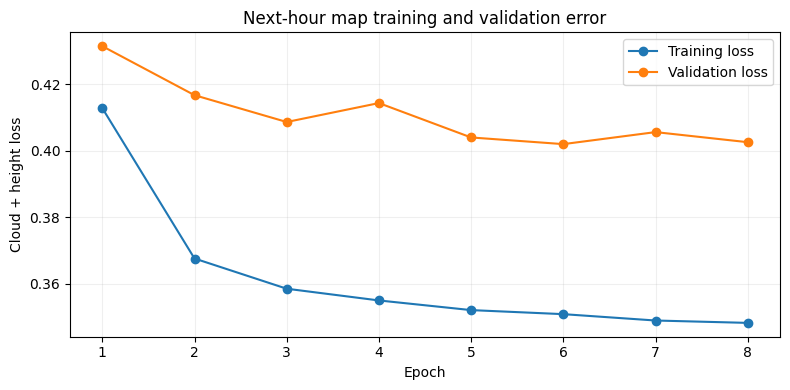

In [59]:
fig, ax = plt.subplots(figsize=(8, 4))
epochs = np.arange(1, len(map_train_history) + 1)
ax.plot(epochs, map_train_history, marker="o", label="Training loss")
ax.plot(epochs, map_val_history, marker="o", label="Validation loss")
ax.set(xlabel="Epoch", ylabel="Cloud + height loss",
       title="Next-hour map training and validation error")
ax.set_xticks(epochs)
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(map_output_dir / "training_error.png", dpi=160)
plt.show()


Compare the trained CNN–LSTM with the last observed map on the test weeks.

In [60]:
test_loss, test_iou, test_height_mae = map_metrics(map_test_loader)
_, baseline_iou, baseline_height_mae = map_metrics(map_test_loader, baseline=True)
print(f"CNN–LSTM | Test cloud IoU: {test_iou:.1f}% | "
      f"Height MAE: {test_height_mae:.2f} km")
print(f"Last map | Test cloud IoU: {baseline_iou:.1f}% | "
      f"Height MAE: {baseline_height_mae:.2f} km")


CNN–LSTM | Test cloud IoU: 85.3% | Height MAE: 1.34 km
Last map | Test cloud IoU: 83.3% | Height MAE: 1.52 km


## Recorded and predicted maps

The six inputs are followed by the recorded next hour and the CNN–LSTM
prediction. Blue marks clear sea, green marks clear land, purple shows cloud
height, and white marks missing data. Both next-hour maps use the same 0–12 km
purple scale.

Import the map colours and the geographic projection if available.

In [61]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

try:
    import cartopy.crs as ccrs
except ImportError:
    ccrs = None  # Geographic coordinates still plot without Cartopy.


Choose an example from the test set.

In [62]:
map_example_number = 100


Run the trained model on the selected six-image sequence.

In [63]:
input_images, actual_cloud_t, actual_h_t, valid_t, _ = map_test_dataset[
    map_example_number
]
map_last_hour = map_sample_t[map_test_idx[map_example_number]]
with torch.no_grad():
    map_scores, map_height = map_model(input_images[None].to(map_device))


Convert the model outputs and recorded target to image arrays.

In [64]:
pred_cloud = (torch.sigmoid(map_scores[0, 0]) >= 0.5).cpu().numpy()
pred_height_km = (map_height[0, 0] * 12).cpu().numpy()
actual_cloud_map = actual_cloud_t[0].bool().numpy()
actual_height_km = actual_h_t[0].numpy() * 12
valid_pixels = valid_t[0].bool().numpy()


Read the image coordinates and select the seven recorded hours.

In [65]:
lat = sat_data["lat"]
lon = sat_data["lon"]
observed_positions = list(range(map_last_hour - K + 1, map_last_hour + 2))


Reconstruct the predicted mask’s sea and land background.

In [66]:
land_pixels = np.any(cloud_mask[map_sample_t[map_train_idx]] == 1, axis=0)
predicted_mask = np.where(land_pixels, 1, 0).astype(np.uint8)
predicted_mask[pred_cloud] = 2
predicted_mask[cloud_mask[map_last_hour] == 3] = 3


Apply the original blue, green, purple, and white map palette.

In [67]:
background = ListedColormap(["#0161c2", "#09773e", "#8e63b9", "#ffffff"])
mask_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], background.N)
projection = {"projection": ccrs.PlateCarree()} if ccrs else {}
transform = {"transform": ccrs.PlateCarree()} if ccrs else {}


Plot six inputs beside the recorded and predicted next-hour maps.

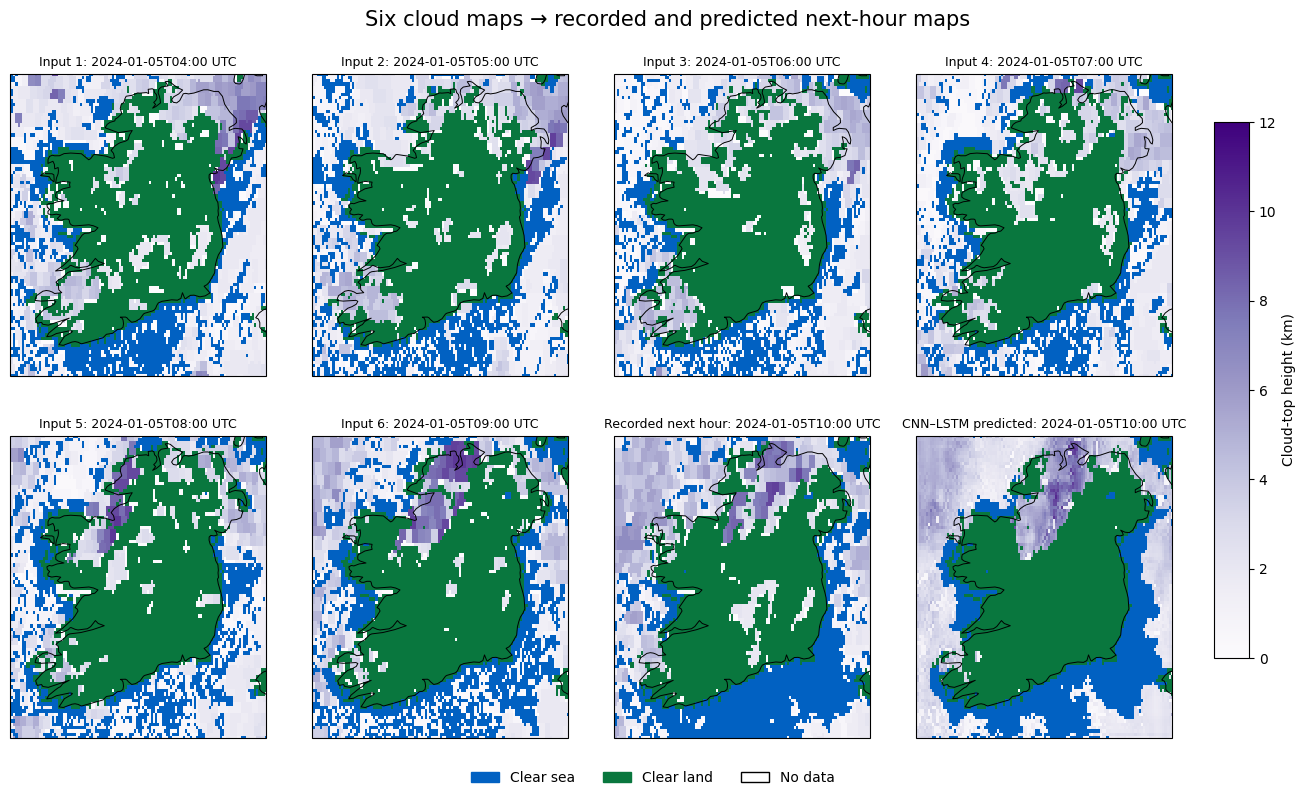

In [68]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8), subplot_kw=projection)
fig.subplots_adjust(left=0.03, right=0.86, bottom=0.07, top=0.90,
                    wspace=0.18, hspace=0.20)

for panel, ax in enumerate(axes.flat):
    if panel < 7:
        position = observed_positions[panel]
        panel_mask = cloud_mask[position]
        panel_height = frames[position, 1].astype(np.float32)
        title = f"Input {panel + 1}" if panel < 6 else "Recorded next hour"
    else:
        position = map_last_hour + 1
        panel_mask = predicted_mask
        panel_height = pred_height_km
        title = "CNN–LSTM predicted"

    ax.pcolormesh(lon, lat, panel_mask, cmap=background, norm=mask_norm,
                  shading="auto", **transform)
    coloured_clouds = ax.pcolormesh(
        lon, lat, np.ma.masked_where(panel_mask != 2, panel_height),
        cmap="Purples", vmin=0, vmax=12, shading="auto", **transform
    )
    if ccrs:
        ax.coastlines(resolution="50m", color="black", linewidth=0.7)
        ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()],
                      crs=ccrs.PlateCarree())
    else:
        ax.set_xlim(lon.min(), lon.max())
        ax.set_ylim(lat.min(), lat.max())
    ax.set_aspect("auto")
    ax.set_title(f"{title}: {str(sat_times[position])[:16]} UTC", fontsize=9)

fig.suptitle("Six cloud maps → recorded and predicted next-hour maps", fontsize=15)
fig.legend(handles=[
    Patch(color="#0161c2", label="Clear sea"),
    Patch(color="#09773e", label="Clear land"),
    Patch(facecolor="#ffffff", edgecolor="black", label="No data"),
], loc="lower center", ncol=3, frameon=False)
fig.colorbar(coloured_clouds, cax=fig.add_axes([0.89, 0.17, 0.025, 0.67]),
             label="Cloud-top height (km)")
fig.savefig(map_output_dir / "recorded_vs_predicted.png", dpi=160,
            bbox_inches="tight")
plt.show()

# Error maps for this example; never use the recorded target as a model input.


Classify incorrect cloud pixels and calculate height error.

In [69]:
pixel_error = np.zeros_like(predicted_mask)
pixel_error[pred_cloud & ~actual_cloud_map & valid_pixels] = 1  # false cloud
pixel_error[~pred_cloud & actual_cloud_map & valid_pixels] = 2  # missed cloud
pixel_error[~valid_pixels] = 3
error_cmap = ListedColormap(["#e4f3e4", "#ff9933", "#d63247", "#ffffff"])
error_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], error_cmap.N)
height_error_map = np.ma.masked_where(
    ~actual_cloud_map, np.abs(pred_height_km - actual_height_km)
)


Plot cloud-pixel mistakes and cloud-top-height error.

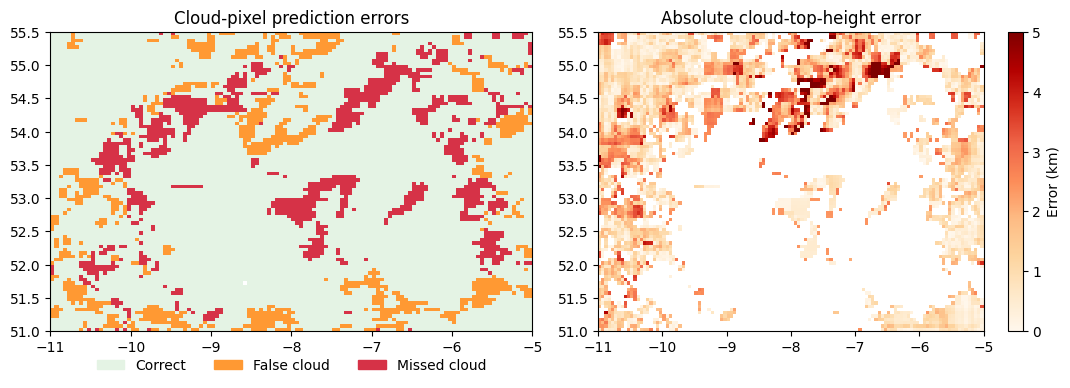

In [70]:
fig, (ax_cloud, ax_height) = plt.subplots(1, 2, figsize=(11, 4))
ax_cloud.pcolormesh(lon, lat, pixel_error, cmap=error_cmap,
                    norm=error_norm, shading="auto")
ax_cloud.set_title("Cloud-pixel prediction errors")
ax_cloud.legend(handles=[
    Patch(color="#e4f3e4", label="Correct"),
    Patch(color="#ff9933", label="False cloud"),
    Patch(color="#d63247", label="Missed cloud"),
], loc="lower center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
colours = ax_height.pcolormesh(lon, lat, height_error_map,
                               cmap="OrRd", vmin=0, vmax=5, shading="auto")
ax_height.set_title("Absolute cloud-top-height error")
fig.colorbar(colours, ax=ax_height, label="Error (km)")
fig.tight_layout()
fig.savefig(map_output_dir / "example_error_maps.png", dpi=160,
            bbox_inches="tight")
plt.show()


Report the saved map and error plots.

In [71]:
print("Saved training_error.png, recorded_vs_predicted.png, and "
      "example_error_maps.png in", map_output_dir.resolve())


Saved training_error.png, recorded_vs_predicted.png, and example_error_maps.png in D:\PhD\radar_cnn_lstm\outputs\project2_next_cloud_map
